# Naive Bayes

            ## 1. Learning objectives

            - Apply probability, conditional probability, Bayes' theorem, and Gaussian distributions
- Implement Gaussian Naive Bayes
- Explain the conditional-independence assumption

            ## 2. Prerequisites

            Basic Python, NumPy arrays, means, and the supervised-learning overview.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Classify by comparing how probable the observed features are under each class.

            ## 4. Real-world use cases

            - Risk classification
- Demand prediction
- Decision-support ranking

            ## 5. Core intuition in simple language

            Begin with each class's prior plausibility, multiply by how compatible each feature is with that class, then normalize conceptually.

## 6. Mathematical foundation

            $$P(C_k\mid\mathbf x)=\frac{P(\mathbf x\mid C_k)P(C_k)}{P(\mathbf x)},\qquad P(\mathbf x\mid C_k)\approx\prod_{j=1}^{p}P(x_j\mid C_k).$$

            **Every symbol:**

            - $C_k$ is class k.
- $P(C_k)$ is prior probability.
- $P(\mathbf x\mid C_k)$ is likelihood.
- $P(\mathbf x)$ is evidence.
- $P(C_k\mid\mathbf x)$ is posterior.
- $p$ is feature count.

            **Why the equation is needed:** Bayes' theorem reverses likelihood into the class probability needed for prediction; the naive product makes estimation practical.

            **Small numerical example:** With sensitivity .9, prevalence .01, and false-positive rate .05, P(disease|positive)=.009/(.009+.0495)=.154.

            **Connection to Python:** The scratch model adds log prior and Gaussian log likelihoods, avoiding unstable multiplication of tiny probabilities.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Define target and success metric
2. Split observations before fitted preprocessing
3. Build a simple baseline
4. Fit a transparent implementation
5. Fit the library estimator
6. Tune with validation evidence
7. Evaluate once on untouched test data

## 9. Implementation from scratch

A readable NumPy version exposes the mechanism and is checked against a tiny hand calculation.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
class GaussianNBScratch:
    def fit(self,features,target):
        self.classes_=np.unique(target)
        self.means_=np.vstack([features[target==label].mean(0) for label in self.classes_])
        self.variances_=np.vstack([features[target==label].var(0)+1e-9 for label in self.classes_])
        self.priors_=np.array([(target==label).mean() for label in self.classes_])
        return self
    def predict_log_proba(self,features):
        scores=[]
        for class_index in range(len(self.classes_)):
            log_prior=np.log(self.priors_[class_index])
            mean=self.means_[class_index]; variance=self.variances_[class_index]
            log_likelihood=-.5*np.sum(np.log(2*np.pi*variance)+(features-mean)**2/variance,axis=1)
            scores.append(log_prior+log_likelihood)
        return np.column_stack(scores)
    def predict(self,features):
        return self.classes_[self.predict_log_proba(features).argmax(1)]

print("Bayes numerical example P(disease|positive):",round((.9*.01)/(.9*.01+.05*.99),3))

Bayes numerical example P(disease|positive): 0.154


## 10. Implementation using a standard library

Scikit-learn adds efficient numerical routines, validation, pipelines, and model-selection compatibility.

## 11. Dataset loading and exploration

The lesson uses a bundled or generated scikit-learn dataset with a fixed seed and no network access.

## 12. Data preprocessing

Train/validation/test roles are separated before scaling or other fitted transformations to prevent data leakage.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Means/variances shapes: (3, 13) (3, 13)
Scratch/library accuracy: 1.0 1.0


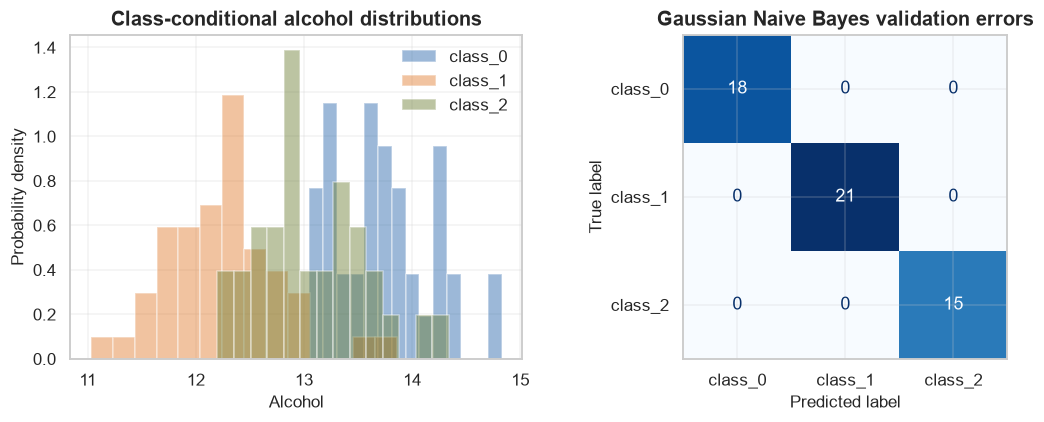

In [3]:
from sklearn.datasets import load_wine
from sklearn.metrics import ConfusionMatrixDisplay,accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

wine=load_wine()
X=wine.data; y=wine.target
X_train,X_validation,y_train,y_validation=train_test_split(X,y,test_size=.3,stratify=y,random_state=RANDOM_SEED)
scratch=GaussianNBScratch().fit(X_train,y_train)
library=GaussianNB().fit(X_train,y_train)
scratch_prediction=scratch.predict(X_validation); library_prediction=library.predict(X_validation)
print("Means/variances shapes:",scratch.means_.shape,scratch.variances_.shape)
print("Scratch/library accuracy:",round(accuracy_score(y_validation,scratch_prediction),3),round(accuracy_score(y_validation,library_prediction),3))
figure,axes=plt.subplots(1,2,figsize=(10,4))
for label,name,color in zip(np.unique(y),wine.target_names,[COURSE_COLORS["blue"],COURSE_COLORS["orange"],COURSE_COLORS["olive"]]):
    axes[0].hist(X_train[y_train==label,0],bins=14,alpha=.45,label=name,color=color,density=True)
axes[0].set(title="Class-conditional alcohol distributions",xlabel="Alcohol",ylabel="Probability density"); axes[0].legend()
ConfusionMatrixDisplay.from_predictions(y_validation,library_prediction,display_labels=wine.target_names,cmap="Blues",colorbar=False,ax=axes[1]); axes[1].set_title("Gaussian Naive Bayes validation errors")
figure.tight_layout(); plt.show()

**How to interpret the result:** Overlapping class-conditional distributions create errors. Agreement with scikit-learn validates the simplified log-probability implementation.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Variance smoothing prevents division by extremely small estimated variances and improves numerical stability.

,var_smoothing,validation_accuracy
0,1.000000e-12,1.0
1,1.000000e-11,1.0
2,1.000000e-10,1.0
3,1.000000e-09,1.0
4,1.000000e-08,1.0
5,1.000000e-07,1.0
6,1.000000e-06,1.0


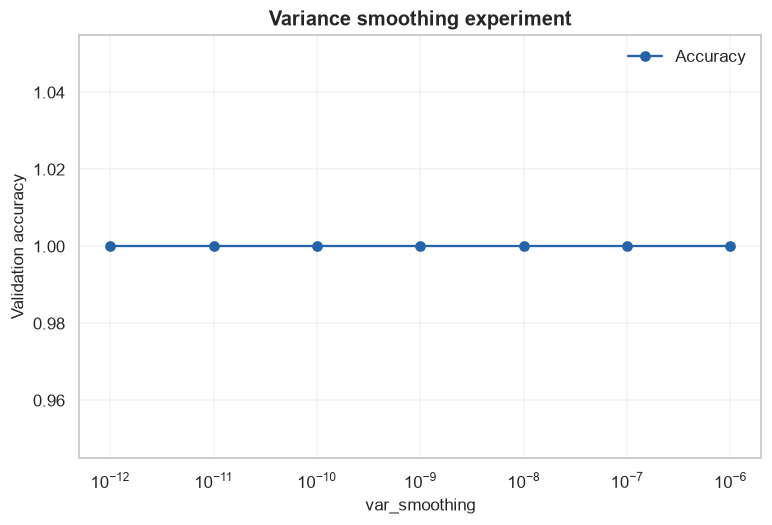

In [4]:
smoothing=np.logspace(-12,-6,7); rows=[]
for value in smoothing:
    candidate=GaussianNB(var_smoothing=value).fit(X_train,y_train)
    rows.append({"var_smoothing":value,"validation_accuracy":candidate.score(X_validation,y_validation)})
smooth_results=pd.DataFrame(rows); display(smooth_results)
figure,axis=plt.subplots(); axis.semilogx(smooth_results["var_smoothing"],smooth_results["validation_accuracy"],marker="o",color=COURSE_COLORS["blue"],label="Accuracy")
axis.set(title="Variance smoothing experiment",xlabel="var_smoothing",ylabel="Validation accuracy"); axis.legend(); plt.show()

## 18. Common mistakes

            - Fitting preprocessing before splitting
- Selecting hyperparameters on test data
- Reporting one metric without a baseline
- Confusing predictive association with causation

            ## 19. Advantages and disadvantages

            **Advantages**

            - Direct objective from labeled examples
- Clear held-out evaluation

            **Disadvantages**

            - Labels can be costly or biased
- Future data may differ from training data

            ## 20. When to use and when not to use the algorithm

            **Use it when:** a trustworthy target represents the decision and representative labeled examples are available.

            **Do not use it when:** labels do not represent the desired outcome or the goal is causal intervention rather than prediction.

## 21. Exercises

1. **Conceptual:** Why must the test set remain untouched during selection?
2. **Mathematical/hand calculation:** Calculate the displayed equation on a small example.
3. **Coding/experimentation:** Change one hyperparameter and explain training-versus-validation behavior.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Repeated test feedback leaks selection information and makes final performance optimistic.
2. Substitute each number, compute in the displayed order, and retain units.
3. Keep the split fixed, retrain each candidate, and prefer stable validation evidence rather than the best training score.

</details>

## 23. Summary and key takeaways

            - Data splitting and preprocessing are part of the model
- Scratch code explains the mechanism while the library version supports realistic use
- Metrics must match error costs
- Generalization—not memorization—is the objective

            ## 24. Further reading

            - [scikit-learn supervised learning guide](https://scikit-learn.org/stable/supervised_learning.html)
- [scikit-learn common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html)